# 02 — Exploratory Data Analysis

**Goal:** Deeply understand the training data to justify every feature engineering decision.

> ✅ We only use the **train split** here. Val and test are invisible.

**Sections:**
1. Load train data
2. Basic info — shape, dtypes, nulls
3. Target analysis — distribution, time plot
4. Seasonality deep-dive — hour, day-of-week, month
5. Autocorrelation analysis — which lags are useful?
6. Weather features vs target
7. Generation features vs target
8. Correlation heatmap
9. Outlier detection
10. Key findings summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED_PATH = '../data/processed/'
TARGET = 'total load actual'

## 1. Load Train Data

In [2]:
train = pd.read_csv(PROCESSED_PATH + 'train.csv')
train['time'] = pd.to_datetime(train['time'], utc=True)
train = train.sort_values('time').reset_index(drop=True)

print(f'Shape:  {train.shape}')
print(f'From:   {train["time"].min().date()}')
print(f'To:     {train["time"].max().date()}')
print(f'Target: {TARGET}')
train.head()

Shape:  (24544, 32)
From:   2014-12-31
To:     2017-10-19
Target: total load actual


,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,272.491463,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,272.512700,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,272.099137,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,...,272.089469,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,...,272.145900,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0


## 2. Basic Info

In [3]:
print('=== DTYPES ===')
print(train.dtypes)
print()
print('=== NULLS ===')
nulls = train.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else 'No nulls ✅')
print()
print('=== DUPLICATES ===')
print(f'Duplicate timestamps: {train["time"].duplicated().sum()}')

=== DTYPES ===
time                                           datetime64[ns, UTC]
generation biomass                                         float64
generation fossil brown coal/lignite                       float64
generation fossil gas                                      float64
generation fossil hard coal                                float64
generation fossil oil                                      float64
generation hydro pumped storage consumption                float64
generation hydro run-of-river and poundage                 float64
generation hydro water reservoir                           float64
generation nuclear                                         float64
generation other                                           float64
generation other renewable                                 float64
generation solar                                           float64
generation waste                                           float64
generation wind onshore                        

In [4]:
train.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
generation biomass,24544.0,402.69,91.45,101.00,342.00,381.00,486.00,592.00
generation fossil brown coal/lignite,24544.0,472.30,367.66,0.00,0.00,559.00,861.00,999.00
generation fossil gas,24544.0,5438.89,2105.89,1518.00,4048.00,4820.00,6124.25,20034.00
generation fossil hard coal,24544.0,4422.01,2033.10,576.00,2595.00,4732.00,6073.00,8359.00
generation fossil oil,24544.0,304.35,54.65,87.00,268.00,303.00,337.00,449.00
generation hydro pumped storage consumption,24544.0,503.03,797.64,0.00,0.00,93.00,698.25,4523.00
generation hydro run-of-river and poundage,24544.0,903.06,370.07,283.00,607.00,805.00,1168.00,1939.00
generation hydro water reservoir,24544.0,2591.31,1886.40,151.00,1005.75,2098.00,3789.25,9389.00
generation nuclear,24544.0,6339.61,820.90,3712.00,5925.00,6752.00,7064.00,7116.00
generation other,24544.0,63.36,21.66,3.00,53.00,58.00,84.00,106.00


## 3. Target Analysis — `total load actual`

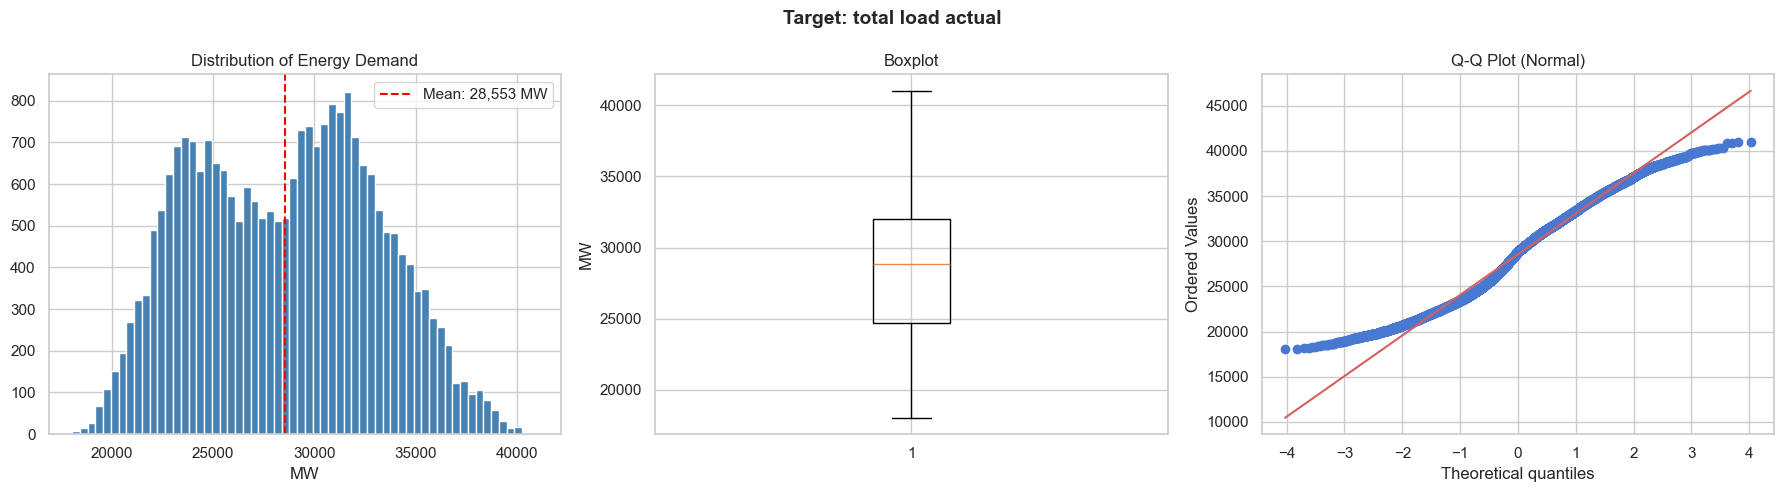

Mean:      28,552.69 MW
Std:        4,536.35 MW
Min:       18,041.00 MW
Max:       41,015.00 MW
Skewness:     0.0682

→ Near-normal distribution — no log-transform needed for energy demand.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
axes[0].hist(train[TARGET], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(train[TARGET].mean(), color='red', linestyle='--', label=f'Mean: {train[TARGET].mean():,.0f} MW')
axes[0].set_title('Distribution of Energy Demand')
axes[0].set_xlabel('MW')
axes[0].legend()

# Boxplot
axes[1].boxplot(train[TARGET], vert=True)
axes[1].set_title('Boxplot')
axes[1].set_ylabel('MW')

# QQ plot
stats.probplot(train[TARGET], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normal)')

plt.suptitle('Target: total load actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean:     {train[TARGET].mean():>10,.2f} MW')
print(f'Std:      {train[TARGET].std():>10,.2f} MW')
print(f'Min:      {train[TARGET].min():>10,.2f} MW')
print(f'Max:      {train[TARGET].max():>10,.2f} MW')
print(f'Skewness: {train[TARGET].skew():>10.4f}')
print()
print('→ Near-normal distribution — no log-transform needed for energy demand.')

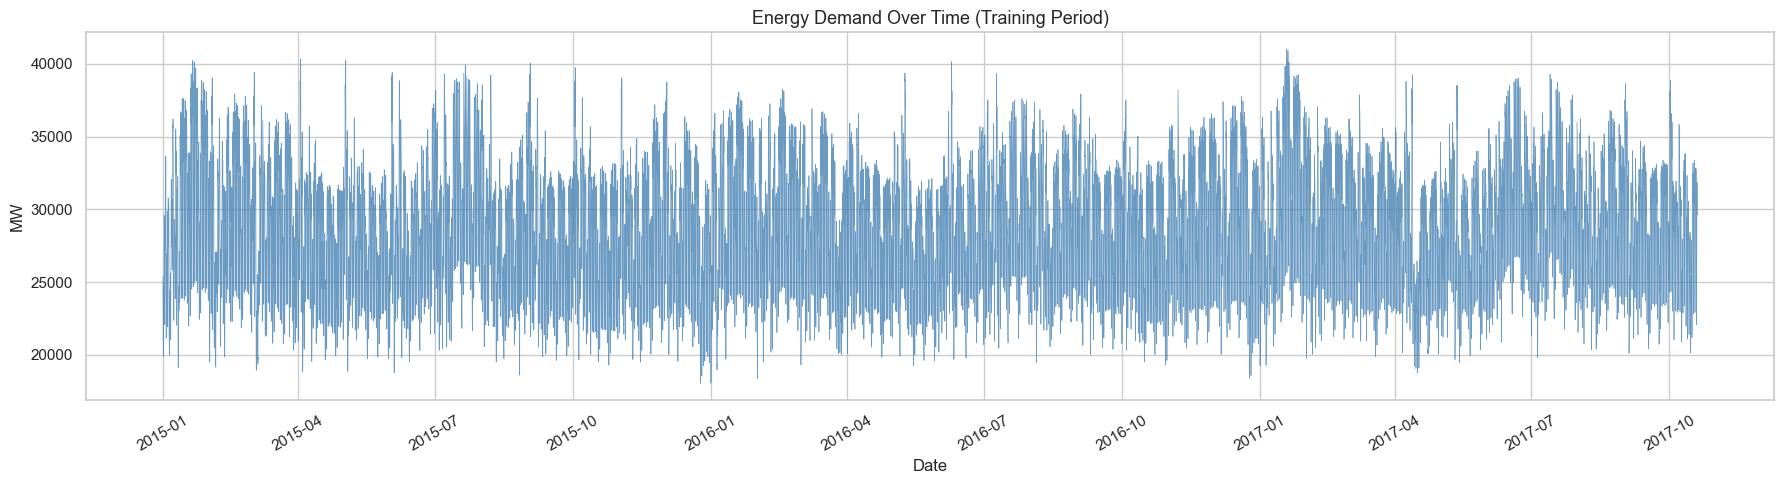

→ Clear annual seasonality visible. No strong upward/downward trend.


In [6]:
# Full time series plot
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(train['time'], train[TARGET], color='steelblue', linewidth=0.5, alpha=0.8)
ax.set_title('Energy Demand Over Time (Training Period)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('MW')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('→ Clear annual seasonality visible. No strong upward/downward trend.')

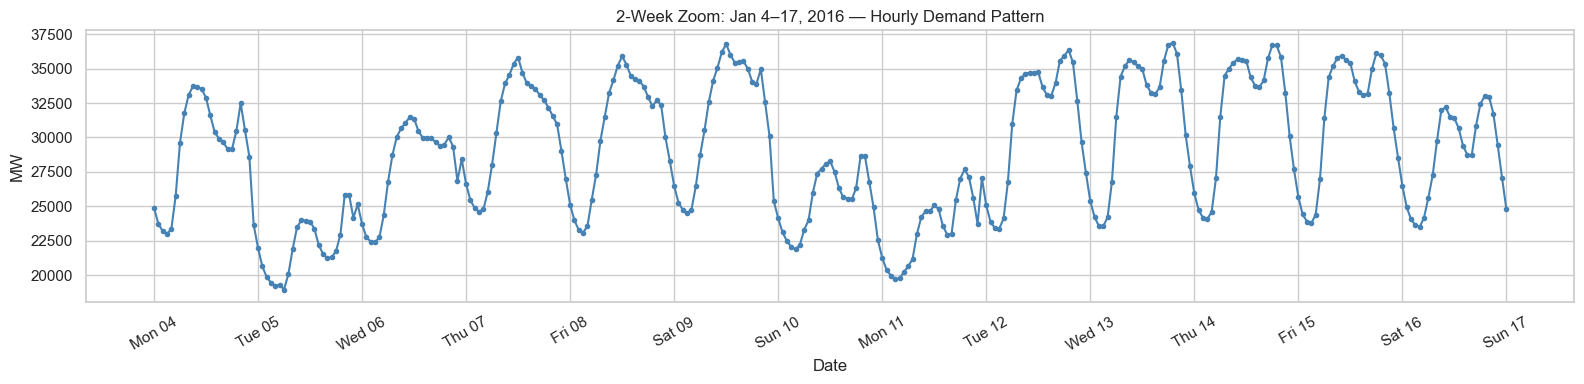

→ Double peak each day: morning (9-11am) and evening (7-9pm).
→ Weekends clearly lower than weekdays.


In [7]:
# Zoom in on 2 weeks to see hourly pattern
sample = train[(train['time'] >= '2016-01-04') & (train['time'] <= '2016-01-17')]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sample['time'], sample[TARGET], color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.set_title('2-Week Zoom: Jan 4–17, 2016 — Hourly Demand Pattern', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('MW')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('→ Double peak each day: morning (9-11am) and evening (7-9pm).')
print('→ Weekends clearly lower than weekdays.')

## 4. Seasonality Deep-Dive

In [8]:
# Add calendar features for analysis
df = train.copy()
df['hour']       = df['time'].dt.hour
df['dow']        = df['time'].dt.dayofweek
df['month']      = df['time'].dt.month
df['year']       = df['time'].dt.year
df['is_weekend'] = df['dow'] >= 5

DOW_NAMES   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

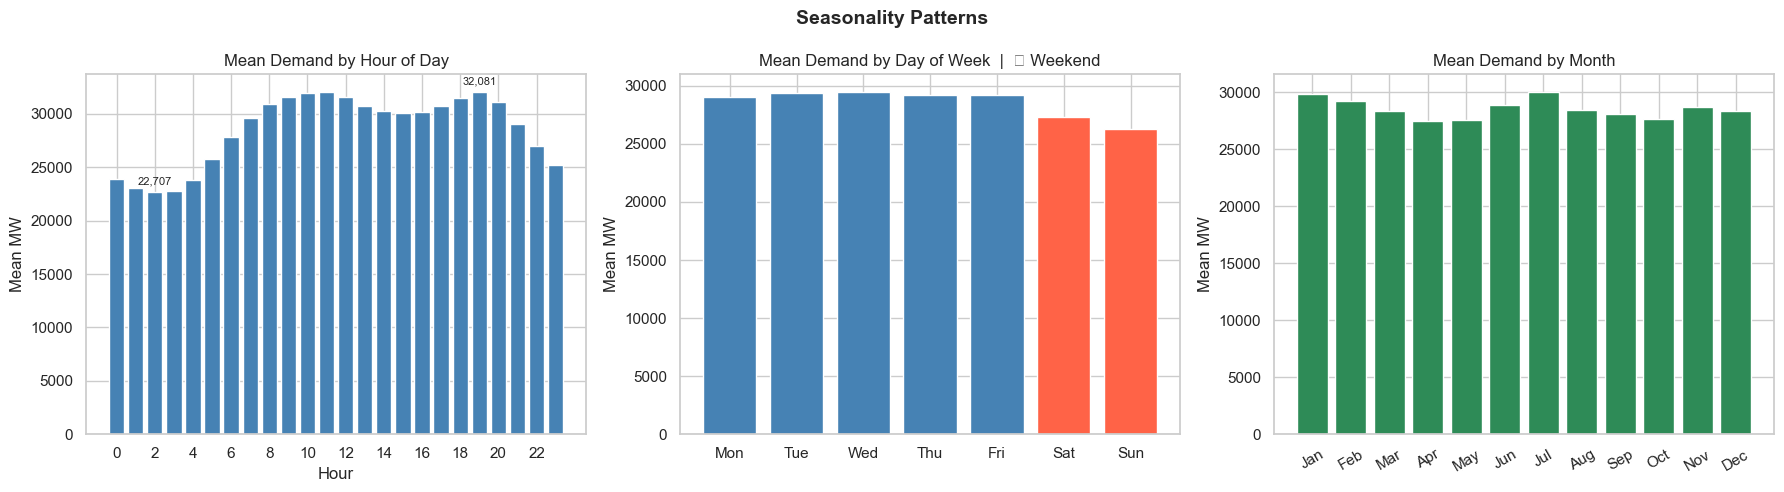

Peak hour:         19:00  (32,081 MW)
Trough hour:       2:00  (22,707 MW)
Peak day:          Wed  (29,502 MW)
Lowest day:        Sun  (26,313 MW)
Weekend reduction: -8.4%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Hour of day ──
hourly = df.groupby('hour')[TARGET].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].set_title('Mean Demand by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean MW')
axes[0].set_xticks(range(0, 24, 2))
for h, v in hourly.items():
    if h in [hourly.idxmax(), hourly.idxmin()]:
        axes[0].annotate(f'{v:,.0f}', (h, v), textcoords='offset points', xytext=(0,5), ha='center', fontsize=8)

# ── Day of week ──
daily = df.groupby('dow')[TARGET].mean()
colors = ['tomato' if d >= 5 else 'steelblue' for d in daily.index]
axes[1].bar(DOW_NAMES, daily.values, color=colors, edgecolor='white')
axes[1].set_title('Mean Demand by Day of Week  |  🔴 Weekend')
axes[1].set_ylabel('Mean MW')

# ── Month ──
monthly = df.groupby('month')[TARGET].mean()
axes[2].bar(MONTH_NAMES, monthly.values, color='seagreen', edgecolor='white')
axes[2].set_title('Mean Demand by Month')
axes[2].set_ylabel('Mean MW')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Seasonality Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Peak hour:         {hourly.idxmax()}:00  ({hourly.max():,.0f} MW)')
print(f'Trough hour:       {hourly.idxmin()}:00  ({hourly.min():,.0f} MW)')
print(f'Peak day:          {DOW_NAMES[daily.idxmax()]}  ({daily.max():,.0f} MW)')
print(f'Lowest day:        {DOW_NAMES[daily.idxmin()]}  ({daily.min():,.0f} MW)')
print(f'Weekend reduction: {((daily[5:].mean() - daily[:5].mean()) / daily[:5].mean() * 100):.1f}%')

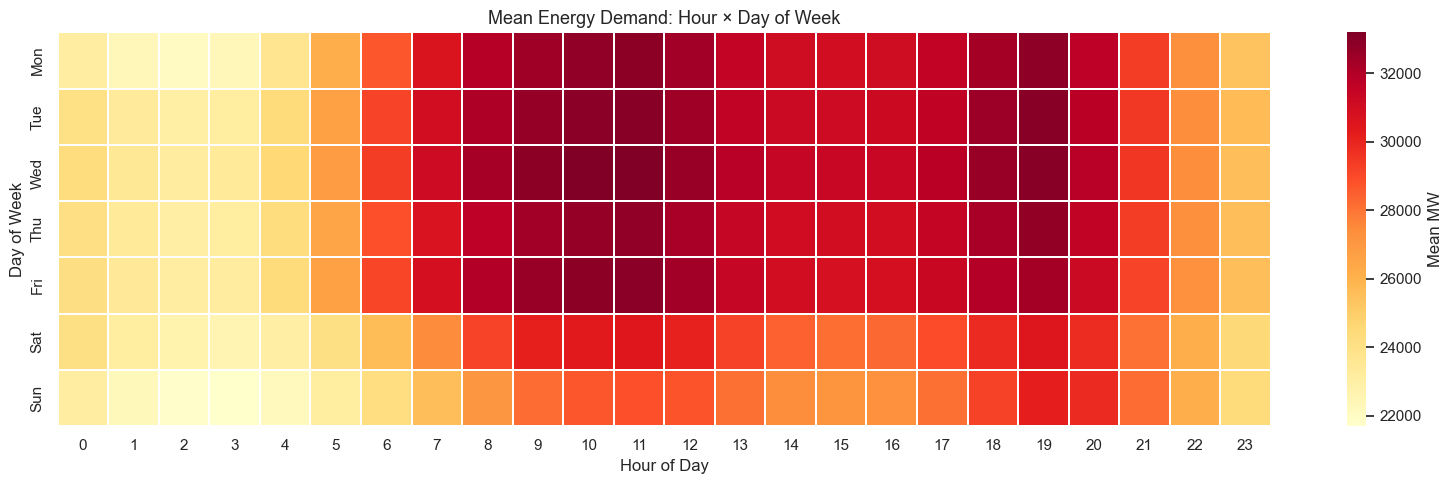

→ Weekday mornings (9-11) and evenings (19-21) are peak demand windows.
→ Weekend has a completely different, flatter profile.


In [10]:
# Heatmap: hour × day-of-week (the most revealing seasonality plot)
pivot = df.groupby(['dow', 'hour'])[TARGET].mean().unstack()
pivot.index = DOW_NAMES

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax,
            linewidths=0.1, cbar_kws={'label': 'Mean MW'})
ax.set_title('Mean Energy Demand: Hour × Day of Week', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()
print('→ Weekday mornings (9-11) and evenings (19-21) are peak demand windows.')
print('→ Weekend has a completely different, flatter profile.')

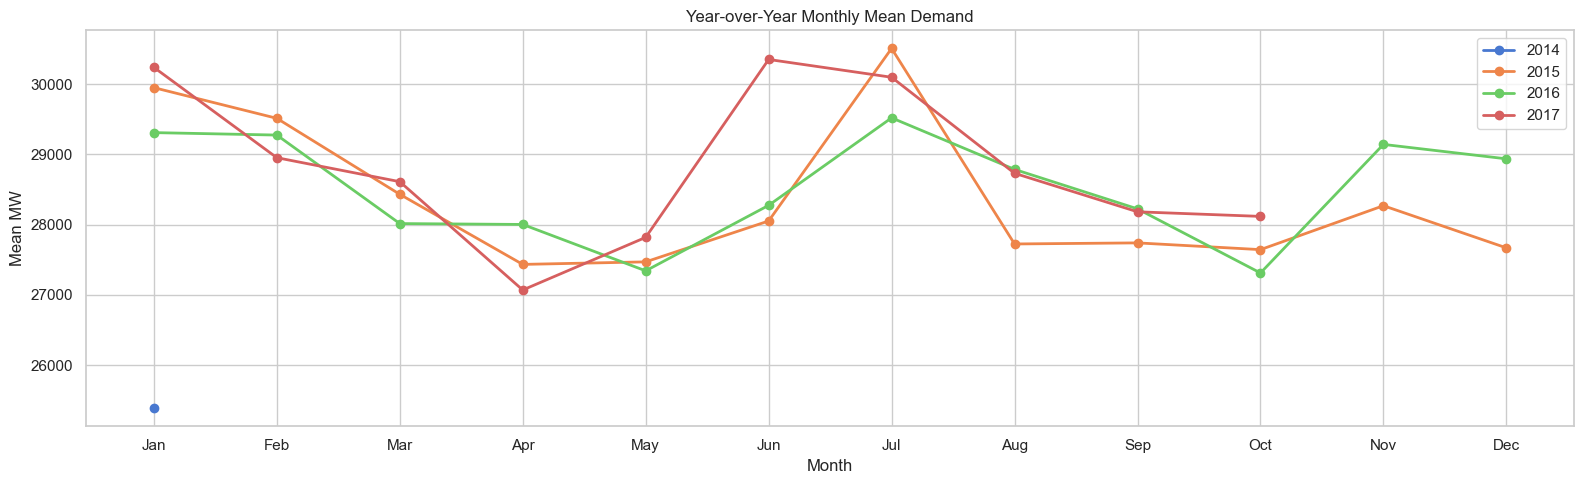

→ Pattern is consistent year-over-year — no major trend shift.


In [11]:
# Year-over-year comparison
fig, ax = plt.subplots(figsize=(16, 5))
colors_yr = {'2015': 'steelblue', '2016': 'seagreen', '2017': 'tomato'}

for year in df['year'].unique():
    yr_data = df[df['year'] == year]
    monthly_yr = yr_data.groupby('month')[TARGET].mean()
    ax.plot(MONTH_NAMES[:len(monthly_yr)], monthly_yr.values,
            label=str(year), linewidth=2, marker='o')

ax.set_title('Year-over-Year Monthly Mean Demand')
ax.set_xlabel('Month')
ax.set_ylabel('Mean MW')
ax.legend()
plt.tight_layout()
plt.show()
print('→ Pattern is consistent year-over-year — no major trend shift.')

## 5. Autocorrelation Analysis — Which Lags Are Useful?

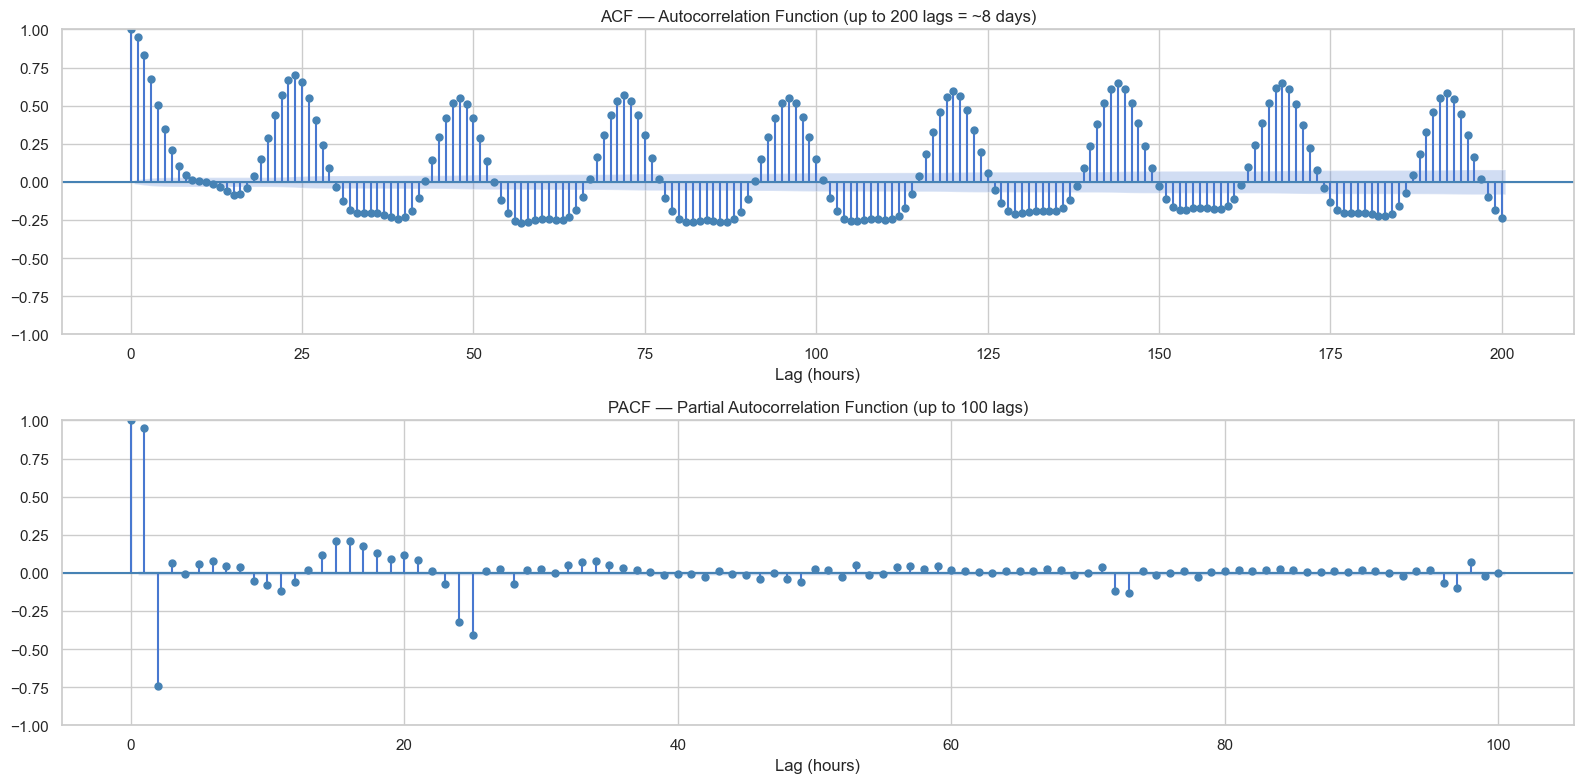

Reading the ACF:
  Spike at lag 1    → demand 1h ago is informative
  Spike at lag 24   → demand same hour yesterday is highly informative
  Spike at lag 48   → 2 days ago
  Spike at lag 168  → same hour last week — very strong
  → These lag values will become our lag features.


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(train[TARGET].dropna(), lags=200, ax=axes[0], alpha=0.05, color='steelblue')
axes[0].set_title('ACF — Autocorrelation Function (up to 200 lags = ~8 days)')
axes[0].set_xlabel('Lag (hours)')

plot_pacf(train[TARGET].dropna(), lags=100, ax=axes[1], alpha=0.05, color='steelblue', method='ywm')
axes[1].set_title('PACF — Partial Autocorrelation Function (up to 100 lags)')
axes[1].set_xlabel('Lag (hours)')

plt.tight_layout()
plt.show()

print('Reading the ACF:')
print('  Spike at lag 1    → demand 1h ago is informative')
print('  Spike at lag 24   → demand same hour yesterday is highly informative')
print('  Spike at lag 48   → 2 days ago')
print('  Spike at lag 168  → same hour last week — very strong')
print('  → These lag values will become our lag features.')

In [13]:
# Compute specific lag correlations
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168, 336]
print('Correlation of target with its own lags:')
print(f'  {"Lag (h)":>10}  {"Correlation":>12}  Meaning')
print('  ' + '-'*55)
for lag in lag_hours:
    r = train[TARGET].corr(train[TARGET].shift(lag))
    tag = '← use' if lag in [1, 24, 48, 168, 336] else ''
    print(f'  lag_{lag:>4}h:    {r:>10.4f}  {tag}')

Correlation of target with its own lags:
     Lag (h)   Correlation  Meaning
  -------------------------------------------------------
  lag_   1h:        0.9509  ← use
  lag_   2h:        0.8330  
  lag_   3h:        0.6766  
  lag_   6h:        0.2072  
  lag_  12h:       -0.0121  
  lag_  24h:        0.7000  ← use
  lag_  48h:        0.5501  ← use
  lag_  72h:        0.5697  
  lag_  96h:        0.5519  
  lag_ 120h:        0.5962  
  lag_ 144h:        0.6495  
  lag_ 168h:        0.6534  ← use
  lag_ 336h:        0.5751  ← use


## 6. Weather Features vs Target

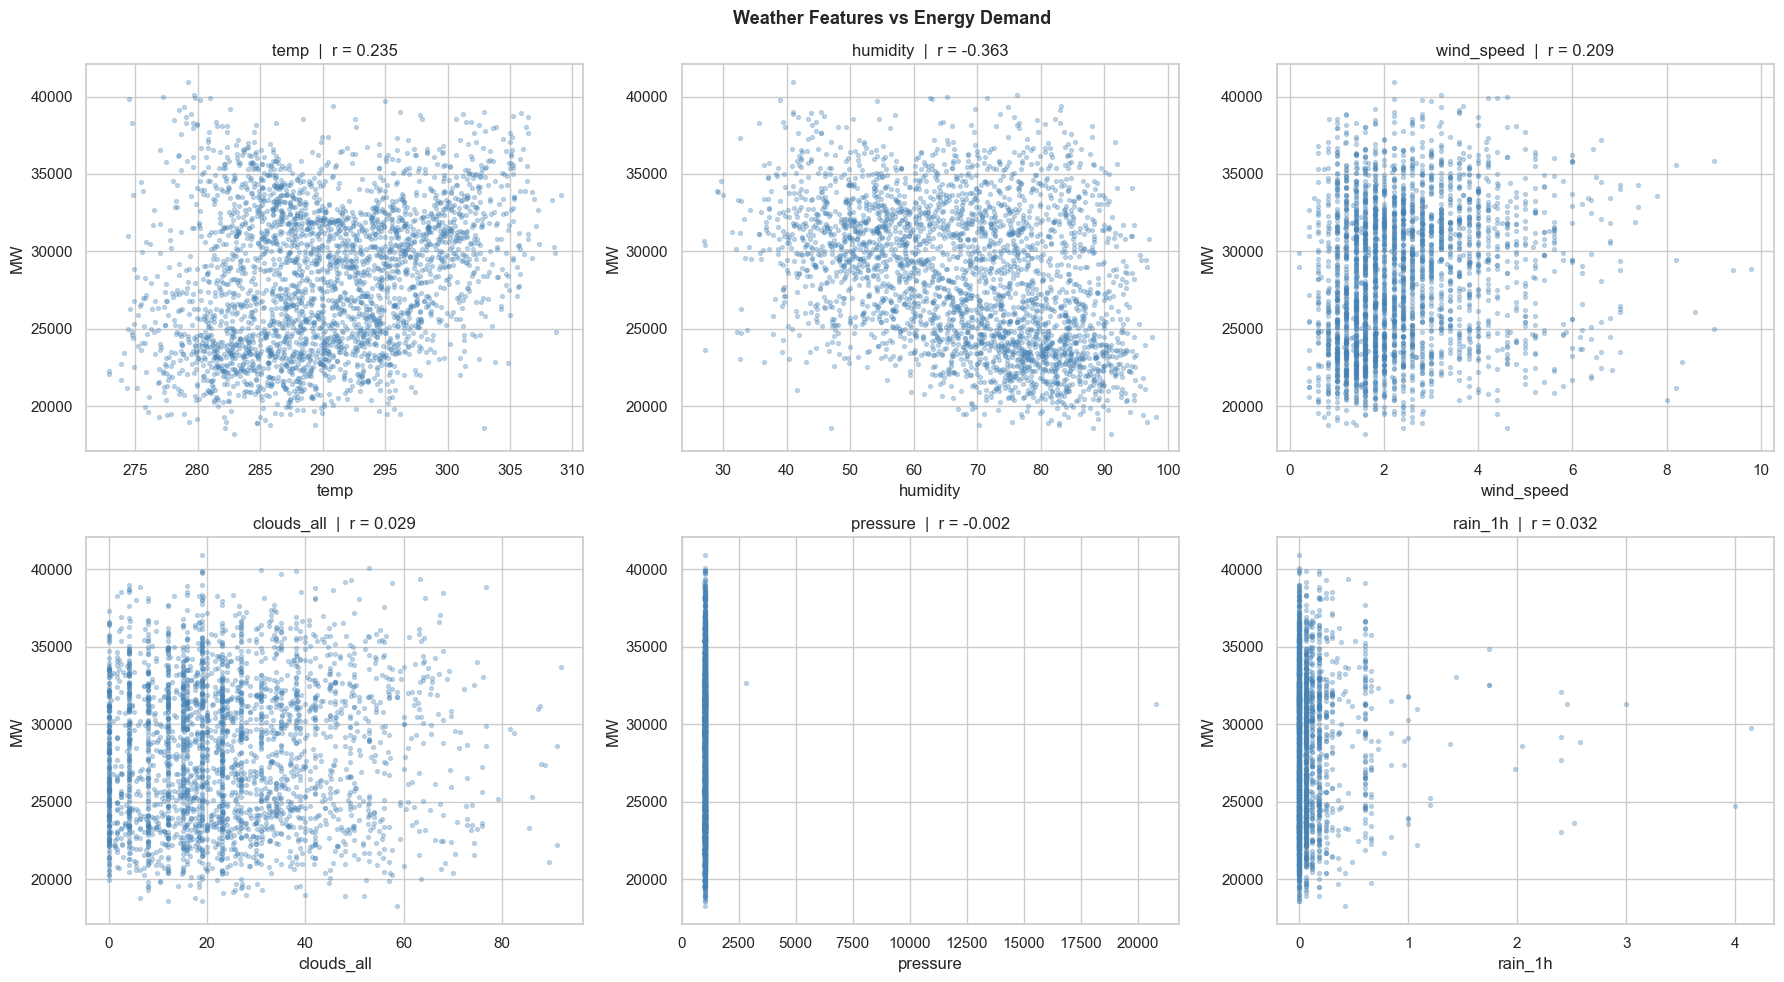

In [14]:
weather_features = ['temp', 'humidity', 'wind_speed', 'clouds_all', 'pressure', 'rain_1h']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(weather_features):
    # Sample to avoid overplotting
    sample = df.sample(3000, random_state=42)
    axes[i].scatter(sample[feat], sample[TARGET], alpha=0.3, s=8, color='steelblue')
    r = df[feat].corr(df[TARGET])
    axes[i].set_title(f'{feat}  |  r = {r:.3f}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('MW')

plt.suptitle('Weather Features vs Energy Demand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

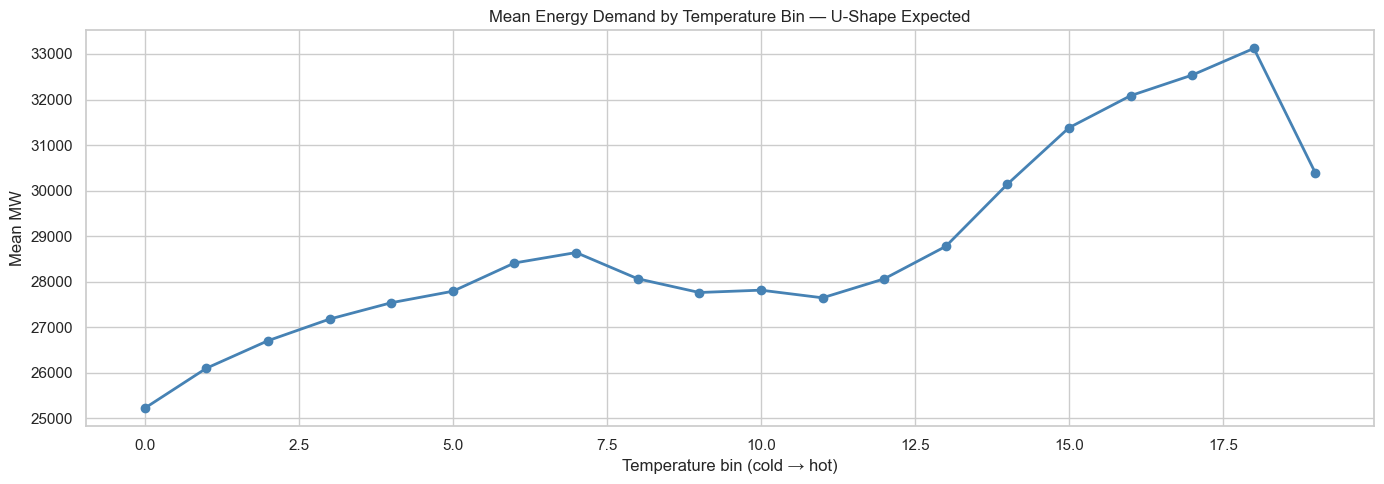

→ Temperature has a U-shaped relationship with demand.
→ temp² feature will capture this non-linearity better than raw temp.
→ Tree models capture it automatically, but it helps linear models too.


In [15]:
# Temperature is special — U-shaped relationship
# Cold = heating demand, Hot = cooling demand, Mild = low demand
temp_bins = pd.cut(df['temp'], bins=20)
temp_demand = df.groupby(temp_bins, observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(temp_demand)), temp_demand.values, color='steelblue', linewidth=2, marker='o')
ax.set_title('Mean Energy Demand by Temperature Bin — U-Shape Expected', fontsize=12)
ax.set_xlabel('Temperature bin (cold → hot)')
ax.set_ylabel('Mean MW')
plt.tight_layout()
plt.show()

print('→ Temperature has a U-shaped relationship with demand.')
print('→ temp² feature will capture this non-linearity better than raw temp.')
print('→ Tree models capture it automatically, but it helps linear models too.')

## 7. Generation Features vs Target

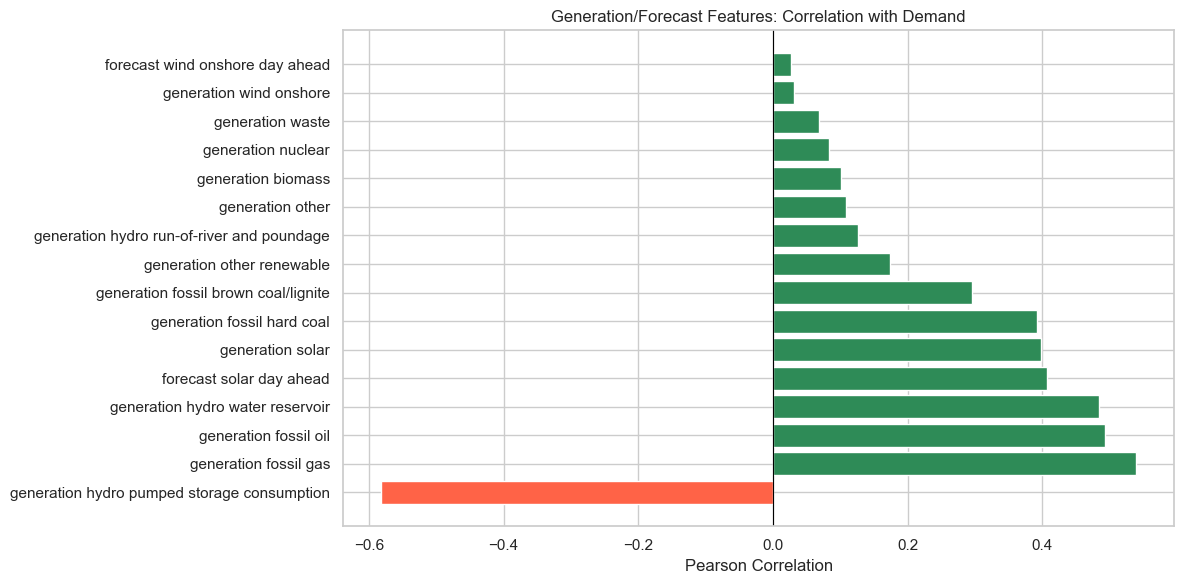

Top positive correlations (higher generation → higher demand):
generation fossil gas                   0.539
generation fossil oil                   0.492
generation hydro water reservoir        0.485
forecast solar day ahead                0.407
generation solar                        0.397
generation fossil hard coal             0.392
generation fossil brown coal/lignite    0.295

Note: generation features are contemporaneous (same hour as target).
Using them as features requires assuming they are available at prediction time.
"total load forecast" IS available ahead of time — keep it as a feature.


In [16]:
# Generation columns (energy supply sources)
gen_cols = [c for c in train.columns
            if c.startswith('generation') or c.startswith('forecast')]

corrs = {col: df[col].corr(df[TARGET]) for col in gen_cols}
corrs = pd.Series(corrs).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['seagreen' if v > 0 else 'tomato' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Generation/Forecast Features: Correlation with Demand', fontsize=12)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top positive correlations (higher generation → higher demand):')
print(corrs[corrs > 0.2].round(3).to_string())
print()
print('Note: generation features are contemporaneous (same hour as target).')
print('Using them as features requires assuming they are available at prediction time.')
print('"total load forecast" IS available ahead of time — keep it as a feature.')

## 8. Correlation Heatmap

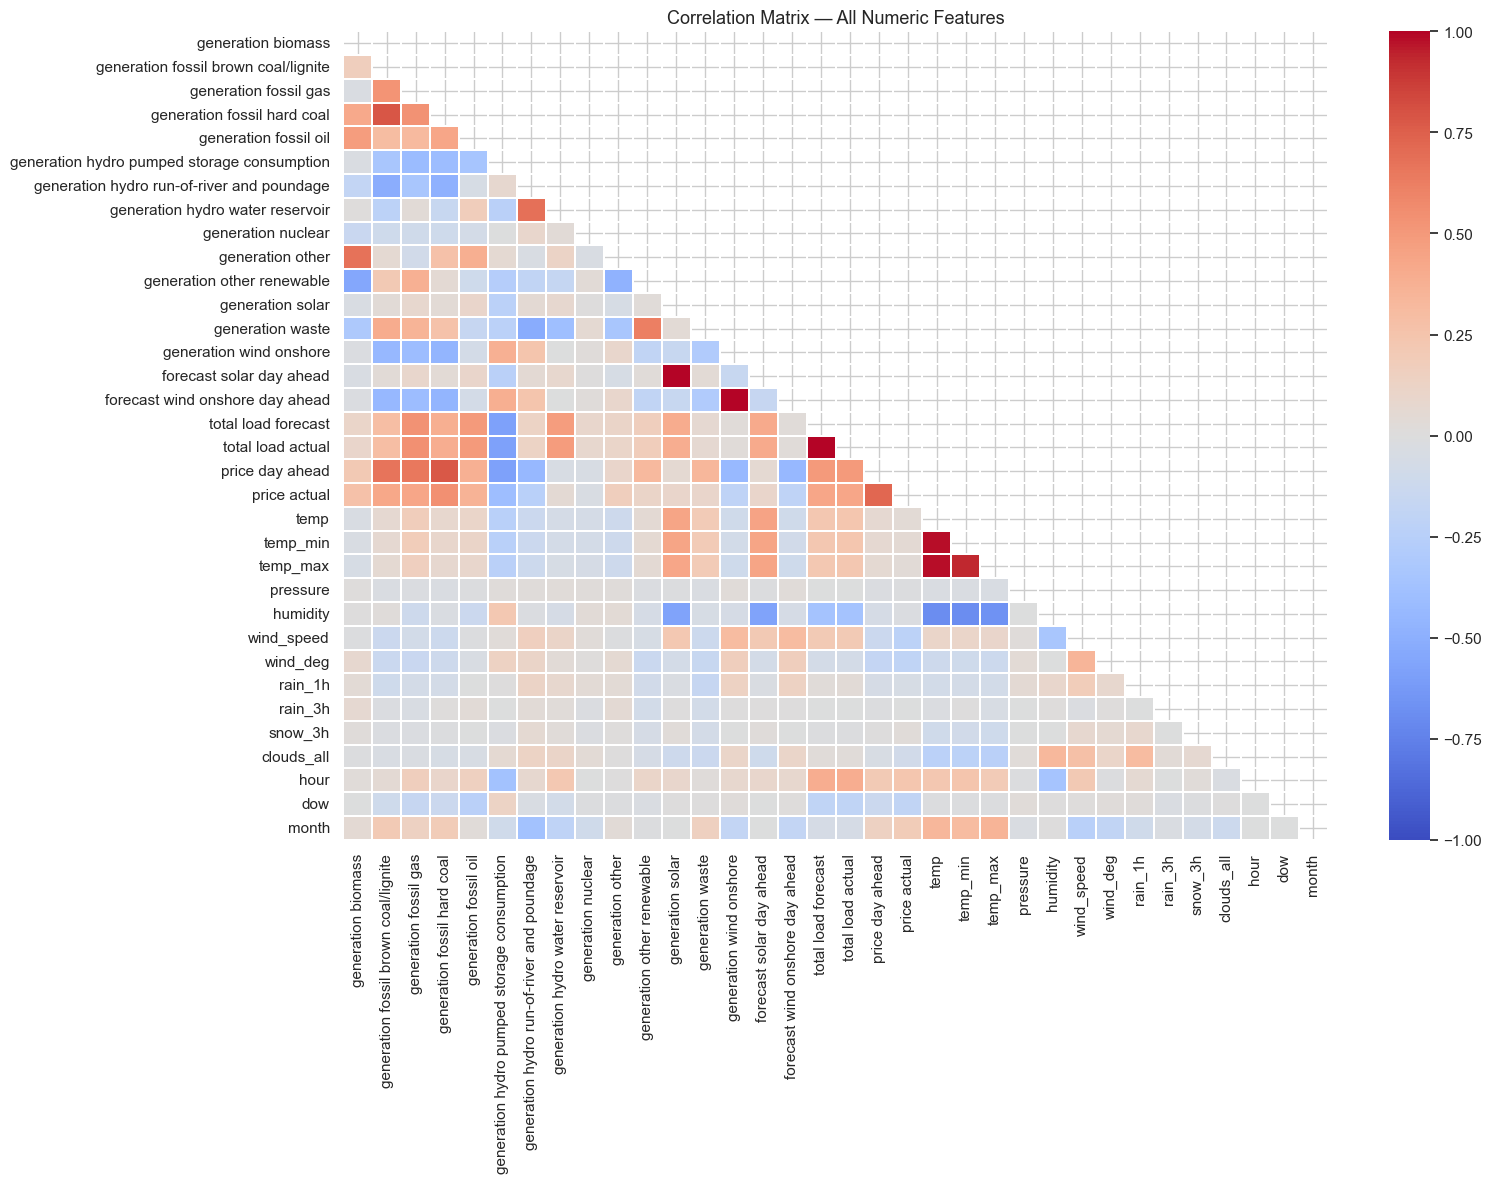

Top 15 features correlated with target:
total load forecast                            0.9945
generation hydro pumped storage consumption    0.5821
generation fossil gas                          0.5393
generation fossil oil                          0.4922
price day ahead                                0.4922
generation hydro water reservoir               0.4846
price actual                                   0.4311
forecast solar day ahead                       0.4066
generation solar                               0.3972
hour                                           0.3948
generation fossil hard coal                    0.3921
humidity                                       0.3634
generation fossil brown coal/lignite           0.2951
temp_min                                       0.2364
temp                                           0.2345


In [17]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Remove columns with low variance or that are purely derived
numeric_cols = [c for c in numeric_cols if c not in ['year']]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — All Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Top 15 features correlated with target:')
print(target_corr.head(15).round(4).to_string())

## 9. Outlier Detection

In [18]:
# Z-score outliers in target
z_scores = np.abs(stats.zscore(df[TARGET].dropna()))
outliers = df[z_scores > 3]

print(f'Target outliers (|z| > 3): {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)')
if len(outliers) > 0:
    print(outliers[['time', TARGET]].to_string())
    print()
    print('Checking if outliers fall on holidays or weekends...')
    outliers = outliers.copy()
    outliers['dow'] = outliers['time'].dt.dayofweek
    outliers['month'] = outliers['time'].dt.month
    print(outliers[['time','dow','month',TARGET]].to_string())

Target outliers (|z| > 3): 0 rows (0.00%)


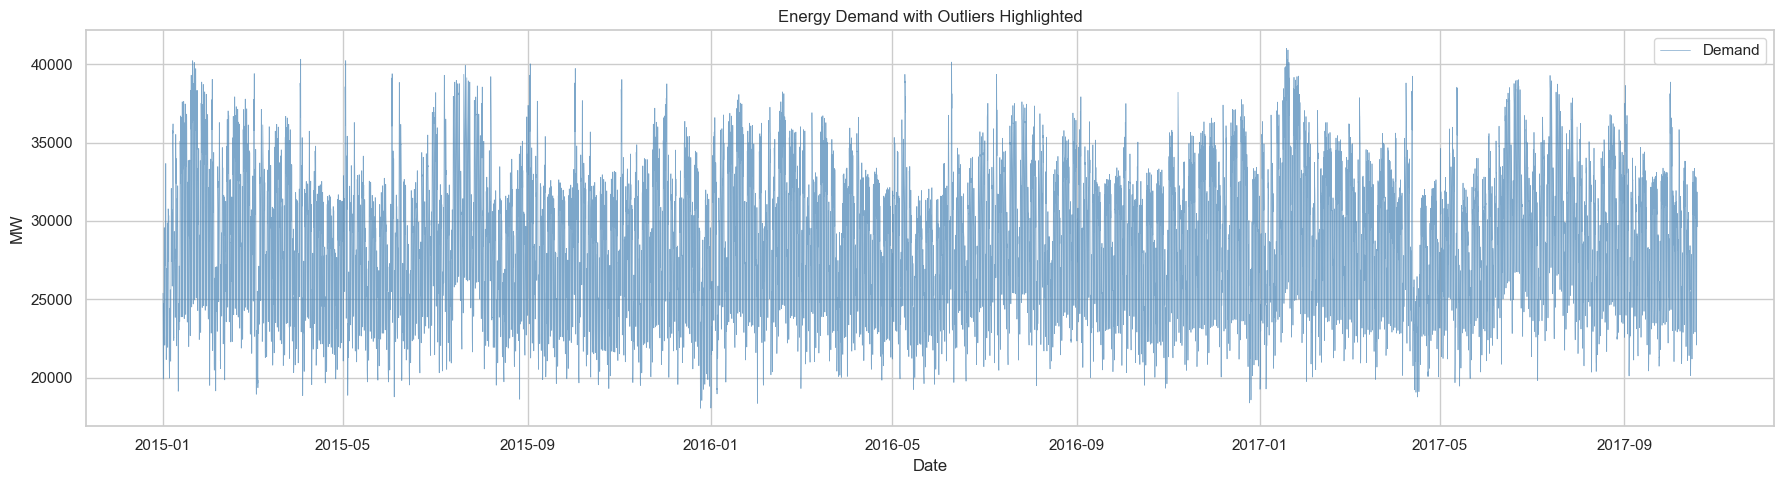

→ Low outliers are likely public holidays (Christmas, Easter, etc.).
→ We keep them — holidays will be captured by is_holiday feature.


In [19]:
# Plot outliers on time series
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['time'], df[TARGET], color='steelblue', linewidth=0.5, alpha=0.7, label='Demand')
if len(outliers) > 0:
    ax.scatter(outliers['time'], outliers[TARGET], color='red', s=40, zorder=5, label='Outliers')
ax.set_title('Energy Demand with Outliers Highlighted')
ax.set_xlabel('Date')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()
print('→ Low outliers are likely public holidays (Christmas, Easter, etc.).')
print('→ We keep them — holidays will be captured by is_holiday feature.')

## 10. Key Findings Summary

| Finding | Feature Engineering Action |
|---|---|
| Strong hourly pattern (morning + evening peaks) | → `hour` as feature, cyclical encoding |
| Strong weekday vs weekend effect | → `dow`, `is_weekend` |
| Annual seasonality (winter/summer peaks) | → `month`, `season`, `day_of_year` |
| Lag 24h has r=0.70 with target | → `lag_24h` — most powerful lag |
| Lag 168h has r=0.66 with target | → `lag_168h` — weekly pattern |
| Temperature has U-shaped relationship | → `temp`, `temp_squared`, `is_cold`, `is_hot` |
| Humidity negatively correlated (r=-0.37) | → `humidity` as feature |
| `total load forecast` exists as column | → Keep as feature (provided by grid operator) |
| Low outliers on holidays | → `is_holiday` binary feature |
| No major upward trend | → No trend detrending needed |
| Distribution is near-normal | → No log-transform of target needed |

**→ All of these drive the decisions in notebook 03.**